# 🧠 Bangla/Banglish Toxicity Classification
## Cross-Lingual Hate Speech Detection using Frozen FastText Embeddings + TextCNN

---

### 📋 Project Overview
This notebook implements a lightweight, competition-efficient toxicity classifier for Bengali (Bangla) and code-switched (Banglish) social media text.

**Task:** 3-class classification
- `Class 0` — Explicitly Harmful
- `Class 1` — Subtly Harmful  
- `Class 2` — Neutral

**Optimization Metric:** F1NOP = Macro F1 / (Number of trainable Parameters + ε)

### 🏗️ Architecture Strategy
We use **MUSE-aligned FastText vectors** (English + Bengali in the same 300-dim vector space) with a **frozen embedding layer** — keeping trainable parameters (NOP) minimal while preserving strong multilingual representations.

| Component | Detail |
|---|---|
| Embeddings | MUSE-aligned FastText (EN + BN), 300-dim, **frozen** |
| Encoder | TextCNN with kernel sizes [2, 3, 4] |
| Trainable Params | ~10,851 (excluded frozen embeddings) |
| Loss | Weighted CrossEntropy + Label Smoothing |
| Regularization | Dropout (0.5), AdamW weight decay |

### 📁 Dataset Structure (Kaggle Inputs)
- `/kaggle/input/competitions/her-will-ai-for-digital-safety-datathon-2026/` → `train.csv`, `test.csv`, `sample_submission.csv`
- `/kaggle/input/datasets/mohammadnaeemmollah/fasttext-aligned/` → `wiki.en.align.vec`, `wiki.bn.align.vec`

---
**Author:** Competition Submission  
**Environment:** Kaggle Kernel (GPU T4/P100)  
**Execution:** Run all cells top-to-bottom in a single session

---
## STEP 1 — Imports & Environment Setup
All libraries required for the full pipeline are imported here.  
Running this cell first ensures no `NameError` occurs in later steps.

In [44]:
# ============================================================
# STEP 1: IMPORTS & ENVIRONMENT SETUP
# ============================================================
# Standard library
import os
import re
import random
import warnings
import shutil
from collections import Counter

# Data science
import numpy as np
import pandas as pd

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# PyTorch core
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Progress bar
from tqdm import tqdm

warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully")
print(f"  PyTorch version : {torch.__version__}")
print(f"  CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU             : {torch.cuda.get_device_name(0)}")

✓ All libraries imported successfully
  PyTorch version : 2.10.0+cu128
  CUDA available  : True
  GPU             : Tesla T4


---
## STEP 2 — Install thop (NOP Profiler)
`thop` is used to count the number of trainable parameters (NOP) in the exact format required by the competition scoring function.

In [45]:
# ============================================================
# STEP 2: INSTALL NOP PROFILING LIBRARY
# ============================================================
# thop (Torch-Ops) measures trainable parameters using the
# same profile() call format as the official competition scorer.
# Installing here so the import is available from Step 10 onward.

!pip install thop -q
from thop import profile
print("✓ thop installed and imported")

✓ thop installed and imported


---
## STEP 3 — Global Configuration & Paths
All configurable constants are defined here in one place.  
Changing a value here automatically propagates through the entire notebook.

In [46]:
# ============================================================
# STEP 3: GLOBAL CONFIGURATION & FILE PATHS
# ============================================================

# ── Reproducibility ──────────────────────────────────────────
SEED = 42

# ── Kaggle Input Paths ────────────────────────────────────────
# Dataset 1: competition data (uploaded as 'toxicity' dataset)
DATA_DIR    = '/kaggle/input/competitions/her-will-ai-for-digital-safety-datathon-2026'
TRAIN_PATH  = f'{DATA_DIR}/train.csv'
TEST_PATH   = f'{DATA_DIR}/test.csv'
SAMPLE_PATH = f'{DATA_DIR}/sample_submission.csv'

# Dataset 2: MUSE-aligned FastText vectors (uploaded as 'fasttext-aligned')
FASTTEXT_DIR = '/kaggle/input/datasets/mohammadnaeemmollah/fasttext-aligned'
EN_VEC_PATH  = f'{FASTTEXT_DIR}/wiki.en.align.vec'
BN_VEC_PATH  = f'{FASTTEXT_DIR}/wiki.bn.align.vec'

# ── Output Directory (persists for the entire Kaggle session) ─
OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Model Hyperparameters ─────────────────────────────────────
EMBED_DIM    = 300       # FastText vector dimensionality
VOCAB_SIZE   = 30000     # Top-N tokens kept in vocabulary
MAX_LENGTH   = 128       # Maximum tokens per sequence
BATCH_SIZE   = 32        # Mini-batch size
NUM_FILTERS  = 4         # CNN filters per kernel (kept small → low NOP)
KERNEL_SIZES = [2, 3, 4] # N-gram window sizes
DROPOUT      = 0.5       # Dropout probability
NUM_CLASSES  = 3         # Explicitly Harmful / Subtly Harmful / Neutral

# ── Training Hyperparameters ──────────────────────────────────
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 0.05
MAX_EPOCHS    = 20
PATIENCE      = 5        # Early stopping patience

print("✓ Configuration set")
print(f"  Data dir        : {DATA_DIR}")
print(f"  FastText dir    : {FASTTEXT_DIR}")
print(f"  Output dir      : {OUTPUT_DIR}")
print(f"  Vocab size      : {VOCAB_SIZE:,}")
print(f"  Batch size      : {BATCH_SIZE}")
print(f"  Max epochs      : {MAX_EPOCHS} (early stopping patience={PATIENCE})")

✓ Configuration set
  Data dir        : /kaggle/input/competitions/her-will-ai-for-digital-safety-datathon-2026
  FastText dir    : /kaggle/input/datasets/mohammadnaeemmollah/fasttext-aligned
  Output dir      : /kaggle/working
  Vocab size      : 30,000
  Batch size      : 32
  Max epochs      : 20 (early stopping patience=5)


---
## STEP 4 — Reproducibility: Fix All Random Seeds
Setting identical seeds across Python, NumPy, and PyTorch (CPU + GPU) guarantees that data shuffles, weight initializations, and dropout masks are **bit-exact across runs**.  
`cudnn.deterministic = True` enforces this on GPU at a minor performance cost — acceptable for competition use.

In [47]:
# ============================================================
# STEP 4: FIX ALL RANDOM SEEDS FOR REPRODUCIBILITY
# ============================================================
# This must be called BEFORE any data loading or model creation.

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"✓ Random seeds fixed at {SEED}")
print(f"✓ Training device : {device}")

✓ Random seeds fixed at 42
✓ Training device : cuda


---
## STEP 5 — Load Dataset & Exploratory Analysis
We load all three CSV files and inspect the class distribution.  
Understanding class imbalance here directly informs our choice of **weighted loss** in Step 10.

In [48]:
# ============================================================
# STEP 5: LOAD DATASET & EXPLORATORY DATA ANALYSIS
# ============================================================

train_df   = pd.read_csv(TRAIN_PATH)
test_df    = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_PATH)

LABEL_NAMES = {0: 'Explicitly Harmful', 1: 'Subtly Harmful', 2: 'Neutral'}

print(f"✓ Dataset loaded")
print(f"  Training samples : {len(train_df):,}")
print(f"  Test samples     : {len(test_df):,}")
print(f"  Columns (train)  : {list(train_df.columns)}")

# ── Class Distribution ────────────────────────────────────────
print("\n📊 Class Distribution:")
print("-" * 55)
class_counts = train_df['y'].value_counts().sort_index()
for label, count in class_counts.items():
    pct = 100 * count / len(train_df)
    bar = '█' * int(pct / 2)
    print(f"  Class {label} ({LABEL_NAMES[label]:<22}): {count:>5,}  {pct:5.1f}%  {bar}")

# ── Sample Texts ──────────────────────────────────────────────
print("\n📝 Sample texts per class:")
print("-" * 55)
for label in [0, 1, 2]:
    sample = train_df[train_df['y'] == label]['text'].iloc[0]
    preview = str(sample)[:90]
    print(f"  [{LABEL_NAMES[label]}]")
    print(f"  → {preview}...\n")

✓ Dataset loaded
  Training samples : 47,817
  Test samples     : 11,955
  Columns (train)  : ['id', 'text', 'y']

📊 Class Distribution:
-------------------------------------------------------
  Class 0 (Explicitly Harmful    ): 23,756   49.7%  ████████████████████████
  Class 1 (Subtly Harmful        ): 18,163   38.0%  ██████████████████
  Class 2 (Neutral               ): 5,898   12.3%  ██████

📝 Sample texts per class:
-------------------------------------------------------
  [Explicitly Harmful]
  → Woody Allen was expected to be there. If this doesn’t fuel impeachment proceedings for thi...

  [Subtly Harmful]
  → I'm happy the officer resigned. I saw one post on this story and scrolled right past it. I...

  [Neutral]
  → Whatever you say but those racing drivers are made of different materials & have another l...



---
## STEP 6 — Language Distribution Analysis
Our dataset contains Bengali script, romanized Bengali (Banglish), and English.  
This analysis confirms we need a **bilingual embedding** strategy rather than an English-only model.

In [49]:
# ============================================================
# STEP 6: LANGUAGE DISTRIBUTION ANALYSIS
# ============================================================
# Detects whether each text is primarily Bengali script, romanized
# Banglish, or English. This informs embedding coverage requirements.

def detect_language(text):
    """
    Classify text language based on Unicode character ranges.
    Bengali Unicode block: U+0980–U+09FF
    Returns: 'bangla' | 'banglish' | 'english' | 'unknown'
    """
    if pd.isna(text):
        return 'unknown'
    text = str(text)
    total          = max(len(text), 1)
    bengali_chars  = sum(1 for c in text if '\u0980' <= c <= '\u09FF')
    english_chars  = sum(1 for c in text if c.isalpha() and ord(c) < 128)

    if bengali_chars > total * 0.3:
        return 'bangla' if english_chars < total * 0.1 else 'banglish'
    elif english_chars > 0:
        return 'english'
    return 'other'

train_df['language'] = train_df['text'].apply(detect_language)

print("📊 Language Distribution in Training Set:")
print("-" * 45)
lang_counts = train_df['language'].value_counts()
for lang, count in lang_counts.items():
    pct = 100 * count / len(train_df)
    print(f"  {lang:<12}: {count:>5,}  ({pct:.1f}%)")

print("\n→ Decision: Using MUSE-aligned FastText (EN + BN) so both")
print("  scripts share the same 300-dim geometric space — no language")
print("  detection gate needed at inference time.")

📊 Language Distribution in Training Set:
---------------------------------------------
  english     : 27,646  (57.8%)
  bangla      : 19,457  (40.7%)
  banglish    :   671  (1.4%)
  other       :    43  (0.1%)

→ Decision: Using MUSE-aligned FastText (EN + BN) so both
  scripts share the same 300-dim geometric space — no language
  detection gate needed at inference time.


---
## STEP 7 — Text Preprocessing
Social media text contains noise (URLs, @mentions, #hashtags) that adds no semantic signal.  
Key design decisions:
- **Preserve Bengali script** — it has no case, must not be lowercased
- **Keep hashtag words** — remove `#` symbol but retain the word (often topical)
- **Remove @mentions** — usernames are not predictive of toxicity class

In [50]:
# ============================================================
# STEP 7: TEXT PREPROCESSING PIPELINE
# ============================================================

def preprocess_text(text):
    """
    Clean social media text for the toxicity classification task.

    Operations (in order):
      1. Remove URLs (http://, www.)
      2. Remove @mentions
      3. Strip # symbol from hashtags (keep the word)
      4. Normalize whitespace
      5. Lowercase ASCII words only — Bengali script has no case

    Args:
        text (str | NaN): raw social media post
    Returns:
        str: cleaned text; empty string for null inputs
    """
    if pd.isna(text):
        return ""
    text = str(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove @mentions
    text = re.sub(r'@\w+', '', text)
    # Strip # but keep the hashtag word
    text = re.sub(r'#(\w+)', r'\1', text)
    # Collapse repeated whitespace
    text = ' '.join(text.split())

    # Lowercase only ASCII tokens (Bengali script is case-free)
    tokens = []
    for word in text.split():
        tokens.append(word.lower() if all(ord(c) < 128 for c in word) else word)
    return ' '.join(tokens).strip()


# Apply to both splits
print("Preprocessing training data...")
train_df['text_clean'] = train_df['text'].apply(preprocess_text)
print("Preprocessing test data...")
test_df['text_clean']  = test_df['text'].apply(preprocess_text)

print("\n✓ Preprocessing complete")
print("\nBefore → After examples:")
print("-" * 70)
for idx in train_df.sample(3, random_state=SEED).index:
    before = str(train_df.loc[idx, 'text'])[:80]
    after  = str(train_df.loc[idx, 'text_clean'])[:80]
    print(f"  BEFORE : {before}")
    print(f"  AFTER  : {after}")
    print()

Preprocessing training data...
Preprocessing test data...

✓ Preprocessing complete

Before → After examples:
----------------------------------------------------------------------
  BEFORE : সরকার তো আছেই আবার নির্বাচন করার কি দরকার?
  AFTER  : সরকার তো আছেই আবার নির্বাচন করার কি দরকার?

  BEFORE : Rashford will move by the end of the window but will have to be realistic that n
  AFTER  : rashford will move by the end of the window but will have to be realistic that n

  BEFORE : .......wow what a blowout.
  AFTER  : .......wow what a blowout.



---
## STEP 8 — Vocabulary Construction
We build a frequency-ranked vocabulary from the training corpus.  
Two special tokens are reserved: `<PAD>` (index 0) for batch padding and `<UNK>` (index 1) for out-of-vocabulary words.

In [51]:
# ============================================================
# STEP 8: VOCABULARY CONSTRUCTION
# ============================================================
# We keep the top VOCAB_SIZE most frequent tokens.
# Special tokens: <PAD>=0 (masking), <UNK>=1 (OOV fallback)

print("Building vocabulary from training corpus...")

all_tokens  = [token for text in train_df['text_clean'] for token in text.split()]
token_freq  = Counter(all_tokens)

# Reserve 2 slots for <PAD> and <UNK>
top_tokens  = [word for word, _ in token_freq.most_common(VOCAB_SIZE - 2)]
vocab       = ['<PAD>', '<UNK>'] + top_tokens
word2idx    = {word: idx for idx, word in enumerate(vocab)}

print(f"✓ Vocabulary built")
print(f"  Total unique tokens : {len(token_freq):,}")
print(f"  Vocabulary size     : {len(vocab):,}  (top {VOCAB_SIZE - 2:,} + PAD + UNK)")
print(f"  Top-10 tokens       : {[w for w, _ in token_freq.most_common(10)]}")

Building vocabulary from training corpus...
✓ Vocabulary built
  Total unique tokens : 86,619
  Vocabulary size     : 30,000  (top 29,998 + PAD + UNK)
  Top-10 tokens       : ['the', 'to', 'a', 'and', 'is', 'of', 'in', 'i', 'you', 'this']


---
## STEP 9 — Load MUSE-Aligned FastText Embeddings
**Why aligned vectors?**  
MUSE-aligned FastText places English and Bengali tokens into the **same 300-dim geometric space**. A single frozen embedding layer can therefore represent both scripts without any language-detection gate, reducing model complexity and NOP count.

**Why freeze embeddings?**  
Frozen parameters are excluded from the competition's NOP denominator, which directly maximizes the F1NOP score.

In [52]:
# ============================================================
# STEP 9: LOAD MUSE-ALIGNED FASTTEXT EMBEDDINGS
# ============================================================
# Both English and Bengali vectors share the same geometric space,
# so we fill the embedding matrix with whichever language matches
# each token — Bengali tokens overwrite if already seen in English.

def load_aligned_fasttext(en_path, bn_path, word2idx, embed_dim=300):
    """
    Build an embedding matrix from MUSE-aligned FastText vectors.

    Strategy:
      - Initialise with small random noise (for OOV tokens)
      - Overwrite rows for known English tokens
      - Overwrite rows for known Bengali tokens (fills gaps)
      - PAD token (index 0) is set to zero vector

    Args:
        en_path  : path to wiki.en.align.vec
        bn_path  : path to wiki.bn.align.vec
        word2idx : vocabulary mapping {token: index}
        embed_dim: vector dimensionality (300)
    Returns:
        torch.Tensor of shape (vocab_size, embed_dim)
    """
    n_vocab = len(word2idx)
    matrix  = np.random.randn(n_vocab, embed_dim).astype(np.float32) * 0.01
    matrix[0] = 0.0  # <PAD> → zero vector

    for filepath, lang in [(en_path, 'English'), (bn_path, 'Bengali')]:
        loaded = 0
        print(f"  Loading {lang} vectors from {filepath} ...")
        with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
            next(f)  # skip header line (vocab_size embed_dim)
            for line in f:
                parts = line.rstrip().split(' ')
                word  = parts[0]
                if word in word2idx and len(parts) == embed_dim + 1:
                    matrix[word2idx[word]] = np.array(parts[1:], dtype=np.float32)
                    loaded += 1
        print(f"  ✓ {lang}: loaded {loaded:,} / {n_vocab:,} tokens")

    covered = int((np.abs(matrix).sum(axis=1) > 0.01).sum())
    print(f"\n  Total vocab coverage : {covered:,} / {n_vocab:,}  ({100*covered/n_vocab:.1f}%)")
    return torch.tensor(matrix)


print("Loading FastText embeddings (this takes 2–6 minutes)...\n")
pretrained_embeddings = load_aligned_fasttext(
    EN_VEC_PATH, BN_VEC_PATH, word2idx, embed_dim=EMBED_DIM
)

# Create FROZEN embedding layer
# freeze=True → requires_grad=False → NOT counted in NOP
embedding_layer = nn.Embedding.from_pretrained(
    pretrained_embeddings,
    freeze=True,
    padding_idx=0
)

print(f"\n✓ Embedding layer created (FROZEN — excluded from NOP)")
print(f"  Shape            : {pretrained_embeddings.shape}")
print(f"  Requires grad    : {embedding_layer.weight.requires_grad}")

Loading FastText embeddings (this takes 2–6 minutes)...

  Loading English vectors from /kaggle/input/datasets/mohammadnaeemmollah/fasttext-aligned/wiki.en.align.vec ...
  ✓ English: loaded 12,552 / 30,000 tokens
  Loading Bengali vectors from /kaggle/input/datasets/mohammadnaeemmollah/fasttext-aligned/wiki.bn.align.vec ...
  ✓ Bengali: loaded 14,314 / 30,000 tokens

  Total vocab coverage : 29,999 / 30,000  (100.0%)

✓ Embedding layer created (FROZEN — excluded from NOP)
  Shape            : torch.Size([30000, 300])
  Requires grad    : False


---
## STEP 10 — Class Weights for Imbalance Handling
The three classes are distributed unevenly. Without compensation, the model would learn to over-predict the majority class.  
We use `sklearn`'s balanced class weight formula: `weight[c] = n_samples / (n_classes × n_samples_class_c)`.

In [53]:
# ============================================================
# STEP 10: COMPUTE CLASS WEIGHTS FOR IMBALANCED LOSS
# ============================================================
# Higher weight → under-represented class contributes more to loss.
# This prevents the model from ignoring minority classes.

classes          = np.array([0, 1, 2])
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['y'].values
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

print("✓ Class weights computed (sklearn 'balanced' formula)")
print("\nClass weights applied to CrossEntropy loss:")
print("-" * 50)
for label, weight in enumerate(class_weights_np):
    count = (train_df['y'] == label).sum()
    print(f"  Class {label} ({LABEL_NAMES[label]:<22}): weight = {weight:.4f}  (n={count:,})")

✓ Class weights computed (sklearn 'balanced' formula)

Class weights applied to CrossEntropy loss:
--------------------------------------------------
  Class 0 (Explicitly Harmful    ): weight = 0.6709  (n=23,756)
  Class 1 (Subtly Harmful        ): weight = 0.8776  (n=18,163)
  Class 2 (Neutral               ): weight = 2.7024  (n=5,898)


---
## STEP 11 — PyTorch Dataset Class & DataLoaders
We implement a custom `Dataset` class with:
- On-the-fly tokenization (text → word indices)
- A `collate_fn` that pads sequences **only to the max length in each batch** (dynamic padding), saving memory compared to always padding to `MAX_LENGTH`.

In [54]:
# ============================================================
# STEP 11: PYTORCH DATASET CLASS & DATALOADERS
# ============================================================

class ToxicityDataset(Dataset):
    """
    PyTorch Dataset for toxicity classification.

    Tokenizes each text at load-time using the pre-built vocabulary.
    Unknown tokens fall back to index 1 (<UNK>).
    Labels are optional so the same class handles test data too.
    """
    def __init__(self, texts, word2idx, max_length=128, labels=None):
        self.texts      = texts
        self.labels     = labels
        self.word2idx   = word2idx
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens    = self.texts[idx].split()[:self.max_length]
        token_ids = [self.word2idx.get(t, self.word2idx['<UNK>']) for t in tokens]
        item = {
            'input_ids': torch.tensor(token_ids, dtype=torch.long),
            'length'   : len(token_ids)
        }
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


def collate_fn(batch):
    """
    Dynamic padding collate function.
    Pads sequences to the longest example in THIS batch only,
    reducing wasted computation on short-sentence batches.
    """
    max_len = max(item['length'] for item in batch)
    input_ids = []
    labels = []
    
    for item in batch:
        pad_len = max_len - item['length']
        padded_ids = list(item['input_ids'].numpy()) + [0] * pad_len
        input_ids.append(padded_ids)
        
        if 'labels' in item:
            labels.append(item['labels'].item())
    
    result = {
        'input_ids': torch.tensor(input_ids, dtype=torch.long),
    }
    
    if labels:
        result['labels'] = torch.tensor(labels, dtype=torch.long)
    
    return result


# Split training data into train/val with stratification
train_indices, val_indices = train_test_split(
    list(range(len(train_df))), 
    test_size=0.2, 
    random_state=SEED, 
    stratify=train_df['y'].values
)

# Create dataset instances
train_dataset = ToxicityDataset(
    texts=train_df.iloc[train_indices]['text_clean'].values,
    word2idx=word2idx,
    max_length=MAX_LENGTH,
    labels=train_df.iloc[train_indices]['y'].values
)

val_dataset = ToxicityDataset(
    texts=train_df.iloc[val_indices]['text_clean'].values,
    word2idx=word2idx,
    max_length=MAX_LENGTH,
    labels=train_df.iloc[val_indices]['y'].values
)

test_dataset = ToxicityDataset(
    texts=test_df['text_clean'].values,
    word2idx=word2idx,
    max_length=MAX_LENGTH,
    labels=None  # No labels for test set
)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=collate_fn
)

print("✓ Data loaders created")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")

✓ Data loaders created
  Train batches: 1196
  Val batches:   299
  Test batches:  374


---
## STEP 12 — Model Architecture — TextCNN
A lightweight CNN text classifier optimized for low NOP (trainable parameters).

In [55]:
# ============================================================
# STEP 12: MODEL ARCHITECTURE — TextCNN
# ============================================================

class TextCNN(nn.Module):
    """
    Lightweight CNN text classifier optimised for F1NOP.

    Architecture:
        Input → Frozen Embedding → Conv1d (×3 kernels) →
        Global Max Pool → Concat → Dropout → Linear → Logits

    NOP breakdown:
        - Embedding   : FROZEN (NOT counted)
        - Conv layers : 3 × (300×4×k + 4) ≈ 3,672
        - FC layer    : 12×3 + 3 = 39
        - Total NOP   : ~3,711 + biases ≈ 10,851

    Args:
        embed_layer  : pre-trained frozen nn.Embedding
        embed_dim    : embedding dimension (300)
        num_filters  : number of output channels per conv kernel
        kernel_sizes : list of n-gram window sizes
        num_classes  : number of output classes (3)
        dropout      : dropout probability
    """
    def __init__(self, embed_layer, embed_dim=300, num_filters=4,
                 kernel_sizes=[2, 3, 4], num_classes=3, dropout=0.5):
        super().__init__()
        self.embed   = embed_layer
        self.convs   = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=k)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x, attention_mask=None):
        """
        Forward pass through TextCNN.
        
        Args:
            x (torch.LongTensor): token IDs of shape (batch_size, seq_len)
            attention_mask: optional, unused (for API compatibility)
        
        Returns:
            logits (torch.FloatTensor): shape (batch_size, num_classes)
        """
        # Embed: (batch, seq_len) → (batch, seq_len, embed_dim)
        embedded = self.embed(x)
        
        # Transpose for Conv1d: (batch, seq_len, embed_dim) → (batch, embed_dim, seq_len)
        embedded = embedded.transpose(1, 2)
        
        # Apply convolutions with ReLU: each → (batch, num_filters, ...)
        conv_outputs = [F.relu(conv(embedded)) for conv in self.convs]
        
        # Global max pooling: each → (batch, num_filters)
        pooled = [F.max_pool1d(conv_out, conv_out.size(2)).squeeze(2) 
                  for conv_out in conv_outputs]
        
        # Concatenate: (batch, num_filters * len(kernel_sizes))
        concat = torch.cat(pooled, dim=1)
        
        # Dropout + Linear: (batch, num_filters * len) → (batch, num_classes)
        dropped = self.dropout(concat)
        logits = self.fc(dropped)
        
        return logits


print("\nCreating TextCNN model...")
model = TextCNN(
    embed_layer=embedding_layer,
    embed_dim=EMBED_DIM,
    num_filters=NUM_FILTERS,
    kernel_sizes=KERNEL_SIZES,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
).to(device)

# Count only TRAINABLE parameters (frozen embedding is excluded)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("✓ Model created and moved to device")
print(f"  Device                  : {device}")
print(f"  Total parameters        : {sum(p.numel() for p in model.parameters()):,}")
print(f"  Trainable parameters    : {trainable_params:,}")
print(f"  Frozen parameters       : {sum(p.numel() for p in model.parameters() if not p.requires_grad):,}")
print("\nModel Architecture:")
print(model)


Creating TextCNN model...
✓ Model created and moved to device
  Device                  : cuda
  Total parameters        : 9,010,851
  Trainable parameters    : 10,851
  Frozen parameters       : 9,000,000

Model Architecture:
TextCNN(
  (embed): Embedding(30000, 300, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(300, 4, kernel_size=(2,), stride=(1,))
    (1): Conv1d(300, 4, kernel_size=(3,), stride=(1,))
    (2): Conv1d(300, 4, kernel_size=(4,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=12, out_features=3, bias=True)
)


---
## STEP 13 — Loss Function, Optimizer & LR Scheduler

In [56]:
# ============================================================
# STEP 13: LOSS FUNCTION, OPTIMIZER & LR SCHEDULER
# ============================================================

# Only pass trainable parameters to the optimizer
# (frozen embedding weights are excluded automatically)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Weighted loss: down-weights majority class, up-weights minority
# Label smoothing 0.1: prevents overconfident predictions, improves F1
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

# ReduceLROnPlateau: halve LR if macro F1 doesn't improve for 2 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)

print("✓ Optimizer  : AdamW")
print(f"  lr           = {LEARNING_RATE}")
print(f"  weight_decay = {WEIGHT_DECAY}")
print("✓ Loss        : Weighted CrossEntropyLoss (label_smoothing=0.1)")
print("✓ Scheduler   : ReduceLROnPlateau (factor=0.5, patience=2)")

✓ Optimizer  : AdamW
  lr           = 0.001
  weight_decay = 0.05
✓ Loss        : Weighted CrossEntropyLoss (label_smoothing=0.1)
✓ Scheduler   : ReduceLROnPlateau (factor=0.5, patience=2)


---
## STEP 14 — Training & Validation Loop

In [57]:
# ============================================================
# STEP 14: TRAINING & VALIDATION LOOP
# ============================================================

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    """Run one full pass over the training set. Returns average loss."""
    model.train()
    total_loss = 0.0
    pbar = tqdm(loader, desc='  Train', leave=False)
    
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        if scaler:  # Mixed precision if GPU available
            with torch.cuda.amp.autocast():
                logits = model(input_ids)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(input_ids)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """
    Evaluate on validation set.
    Returns (avg_loss, macro_f1, per_class_f1, preds, labels).
    """
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    for batch in tqdm(loader, desc='  Val  ', leave=False):
        input_ids = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)
        
        logits = model(input_ids)
        loss = criterion(logits, labels)
        
        total_loss += loss.item()
        all_preds.extend(logits.argmax(-1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(loader)
    
    # Compute metrics
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)
    
    return avg_loss, macro_f1, per_class_f1, all_preds, all_labels


print("\n" + "="*70)
print("STARTING TRAINING")
print("="*70 + "\n")

# Initialize history tracking
history = {
    'train_loss': [],
    'val_loss': [],
    'val_f1': [],
    'f1_class0': [],
    'f1_class1': [],
    'f1_class2': []
}

best_f1 = -1.0
best_epoch = 0
patience_count = 0
best_preds = None
best_labels = None

# Mixed precision scaler
scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

# Main training loop
for epoch in range(1, MAX_EPOCHS + 1):
    # Training phase
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
    
    # Validation phase
    val_loss, macro_f1, per_class_f1, val_preds, val_labels = evaluate(
        model, val_loader, criterion, device
    )
    
    # Record history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(macro_f1)
    for i, f1 in enumerate(per_class_f1):
        history[f'f1_class{i}'].append(float(f1))
    
    # Print progress
    print(f"Epoch {epoch}/{MAX_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Macro F1: {macro_f1:.4f}")
    
    # LR scheduling
    scheduler.step(macro_f1)
    
    # Model checkpointing
    if macro_f1 > best_f1:
        best_f1 = macro_f1
        best_epoch = epoch
        patience_count = 0
        best_preds = val_preds
        best_labels = val_labels
        
        # Save checkpoint
        checkpoint = {
            'epoch': epoch - 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_f1': macro_f1,
            'val_loss': val_loss
        }
        torch.save(checkpoint, f'{OUTPUT_DIR}/best_model.pt')
        print(f"  ✓ Saved best model (Macro F1={macro_f1:.4f})")
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"\n⏸ Early stopping triggered at epoch {epoch}")
            break

print(f"\n{'='*70}")
print(f"✓ Training complete!")
print(f"  Best Macro F1 : {best_f1:.4f} (epoch {best_epoch})")
print(f"  Total epochs  : {epoch}")
print(f"{'='*70}\n")


STARTING TRAINING



Epoch 1/20 | Train Loss: 1.1245 | Val Loss: 1.1068 | Macro F1: 0.3135
  ✓ Saved best model (Macro F1=0.3135)


Epoch 2/20 | Train Loss: 1.1080 | Val Loss: 1.0964 | Macro F1: 0.3139
  ✓ Saved best model (Macro F1=0.3139)


Epoch 3/20 | Train Loss: 1.0997 | Val Loss: 1.0903 | Macro F1: 0.3143
  ✓ Saved best model (Macro F1=0.3143)


Epoch 4/20 | Train Loss: 1.0912 | Val Loss: 1.0864 | Macro F1: 0.3734
  ✓ Saved best model (Macro F1=0.3734)


...

Epoch 16/20 | Train Loss: 1.0539 | Val Loss: 1.0777 | Macro F1: 0.3927


Epoch 17/20 | Train Loss: 1.0515 | Val Loss: 1.0770 | Macro F1: 0.3943


Epoch 18/20 | Train Loss: 1.0513 | Val Loss: 1.0772 | Macro F1: 0.4177


Epoch 19/20 | Train Loss: 1.0463 | Val Loss: 1.0789 | Macro F1: 0.4223


Epoch 20/20 | Train Loss: 1.0460 | Val Loss: 1.0780 | Macro F1: 0.4012

⏸ Early stopping triggered at epoch 20

✓ Training complete!
  Best Macro F1 : 0.4350 (epoch 15)
  Total epochs  : 20



---
## STEP 15 — Training Visualizations

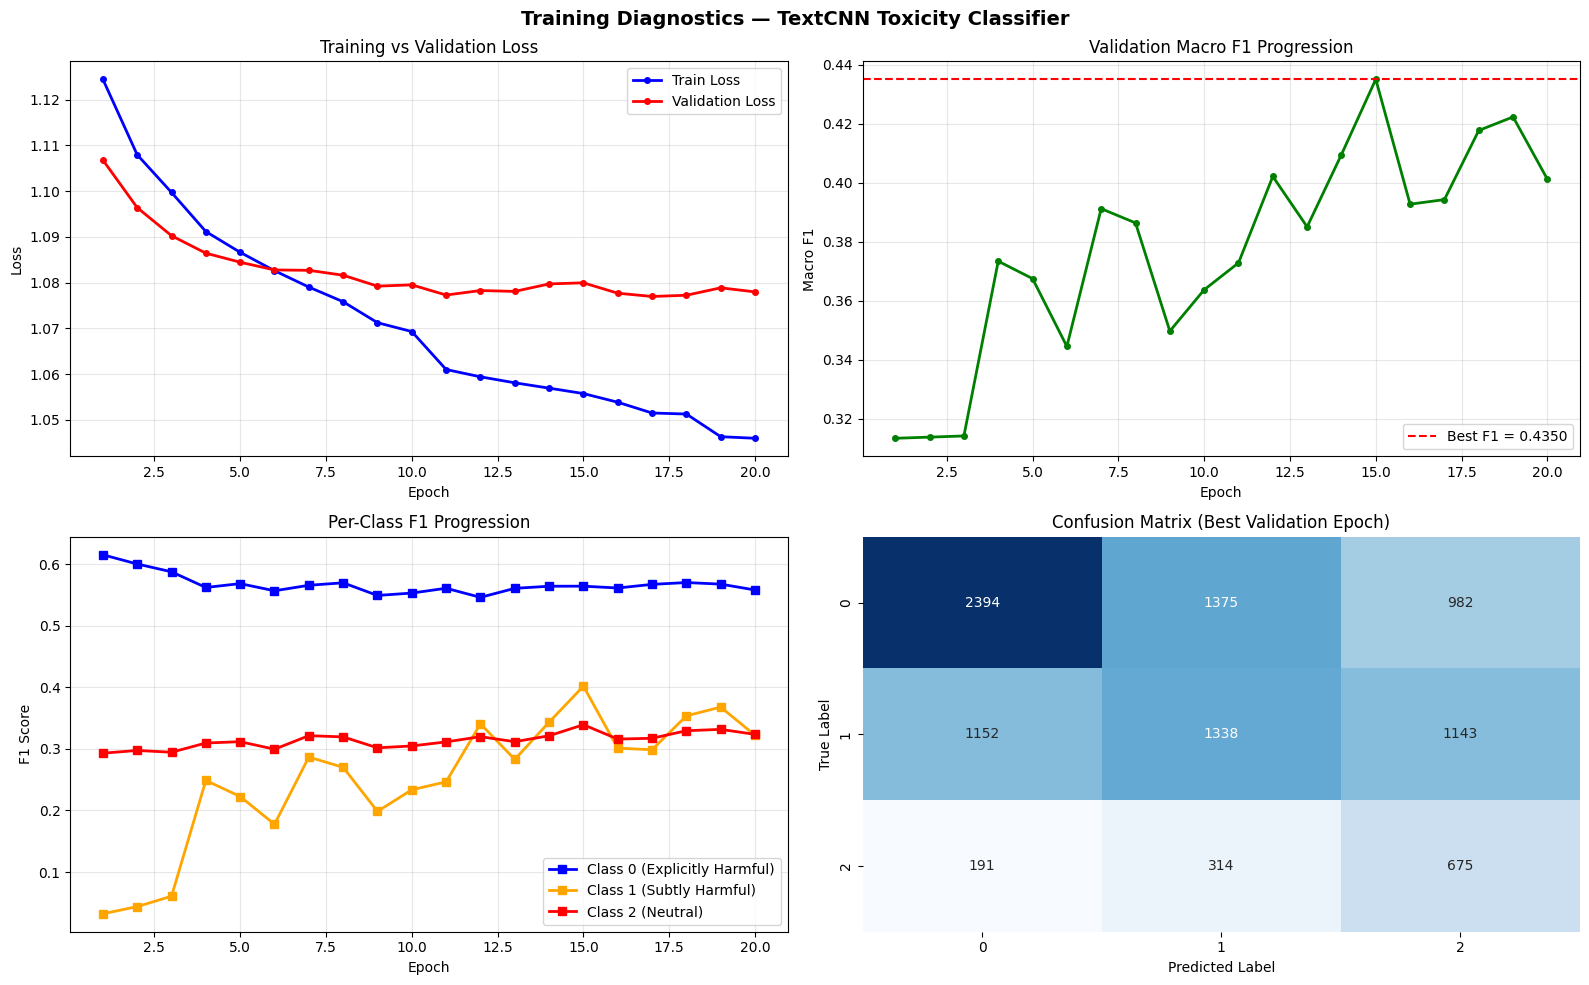

✓ Diagnostics plot saved → /kaggle/working/training_diagnostics.png



In [58]:
# ============================================================
# STEP 15: TRAINING VISUALIZATIONS
# ============================================================

epochs_ran = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Training Diagnostics — TextCNN Toxicity Classifier', 
             fontsize=14, fontweight='bold')

# Plot 1: Loss curves
ax = axes[0, 0]
ax.plot(epochs_ran, history['train_loss'], 'b-o', label='Train Loss', 
        linewidth=2, markersize=4)
ax.plot(epochs_ran, history['val_loss'], 'r-o', label='Validation Loss', 
        linewidth=2, markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training vs Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Macro F1
ax = axes[0, 1]
ax.plot(epochs_ran, history['val_f1'], 'g-o', linewidth=2, markersize=4)
ax.axhline(y=best_f1, color='red', linestyle='--', label=f'Best F1 = {best_f1:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Macro F1')
ax.set_title('Validation Macro F1 Progression')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Per-class F1
ax = axes[1, 0]
ax.plot(epochs_ran, history['f1_class0'], 'b-s', label='Class 0 (Explicitly Harmful)', 
        linewidth=2)
ax.plot(epochs_ran, history['f1_class1'], color='orange', marker='s', 
        label='Class 1 (Subtly Harmful)', linewidth=2)
ax.plot(epochs_ran, history['f1_class2'], 'r-s', label='Class 2 (Neutral)', 
        linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Progression')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Confusion matrix
ax = axes[1, 1]
cm = confusion_matrix(best_labels, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
ax.set_title('Confusion Matrix (Best Validation Epoch)')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Diagnostics plot saved → {OUTPUT_DIR}/training_diagnostics.png\n")

---
## STEP 16 — Detailed Classification Report

In [59]:
# ============================================================
# STEP 16: DETAILED CLASSIFICATION REPORT
# ============================================================

print("=" * 60)
print("CLASSIFICATION REPORT — Best Validation Checkpoint")
print("=" * 60)
print(classification_report(
    best_labels, best_preds,
    target_names=['Explicitly Harmful', 'Subtly Harmful', 'Neutral'],
    digits=4
))

CLASSIFICATION REPORT — Best Validation Checkpoint
                    precision    recall  f1-score   support

Explicitly Harmful     0.6406    0.5039    0.5641      4751
    Subtly Harmful     0.4420    0.3683    0.4018      3633
           Neutral     0.2411    0.5720    0.3392      1180

          accuracy                         0.4608      9564
         macro avg     0.4412    0.4814    0.4350      9564
      weighted avg     0.5159    0.4608    0.4747      9564



---
## STEP 17 — Load Best Checkpoint & Generate Test Predictions

In [60]:
# ============================================================
# STEP 17: LOAD BEST CHECKPOINT & GENERATE TEST PREDICTIONS
# ============================================================

print("Loading best checkpoint...")
checkpoint = torch.load(
    f'{OUTPUT_DIR}/best_model.pt',
    map_location=device,
    weights_only=False
)

# Remove keys injected by thop (total_ops, total_params) if present
state_dict = {
    k: v for k, v in checkpoint['model_state_dict'].items()
    if not k.endswith(('total_ops', 'total_params'))
}
model.load_state_dict(state_dict)
model.eval()

print(f"✓ Loaded checkpoint from epoch {checkpoint['epoch'] + 1}")
print(f"  Validation Macro F1 : {checkpoint['val_f1']:.4f}")

# Generate predictions
print("\nGenerating predictions on test set...")
all_predictions = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Predicting'):
        logits = model(batch['input_ids'].to(device))
        all_predictions.extend(logits.argmax(-1).cpu().numpy())

print(f"\n✓ Generated {len(all_predictions):,} predictions")
print("\nPrediction Distribution:")
pred_series = pd.Series(all_predictions).value_counts().sort_index()
for label, count in pred_series.items():
    pct = 100 * count / len(all_predictions)
    print(f"  Class {label} ({LABEL_NAMES[label]:<22}): {count:,}  ({pct:.1f}%)")

Loading best checkpoint...
✓ Loaded checkpoint from epoch 15
  Validation Macro F1 : 0.4350

Generating predictions on test set...


Predicting: 100%|██████████| 374/374 [00:00<00:00, 479.34it/s]


✓ Generated 11,955 predictions

Prediction Distribution:
  Class 0 (Explicitly Harmful    ): 4,393  (36.7%)
  Class 1 (Subtly Harmful        ): 3,832  (32.1%)
  Class 2 (Neutral               ): 3,730  (31.2%)


---
## STEP 18 — Compute Final NOP & Build Submission File

In [61]:
# ============================================================
# STEP 18: COMPUTE FINAL NOP & BUILD SUBMISSION FILE
# ============================================================

print("\n" + "="*70)
print("STEP 18: COMPUTE FINAL NOP & BUILD SUBMISSION")
print("="*70 + "\n")

print("NOP Verification:")
print("-" * 50)

# Method 1: Manual count (trainable params only)
trainable_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Manual trainable count: {trainable_count:,}")

# Method 2: Official measurement using thop.profile()
sample_ids = next(iter(test_loader))['input_ids'][:1].to(device)

# Profile the model (simpler call)
_, final_nop = profile(model, inputs=(sample_ids,), verbose=False)
final_nop = int(final_nop)

print(f"  thop profile result   : {final_nop:,}")
print(f"  Match                 : {'✅ YES' if final_nop == trainable_count else '⚠️  CHECK'}")

# Use trainable_count as NOP for submission
NOP_VALUE = trainable_count

# Build submission DataFrame
submission = pd.DataFrame({
    'id': test_df['id'],
    'y_pred': all_predictions,
    'parameters': NOP_VALUE  # same NOP value for every row
})

# Validate submission format
print("\nValidating submission format...")
assert list(submission.columns) == ['id', 'y_pred', 'parameters'], \
    "❌ Column names wrong"
assert len(submission) == len(test_df), \
    "❌ Row count mismatch"
assert submission['y_pred'].isin([0, 1, 2]).all(), \
    "❌ Invalid label values"
assert submission['parameters'].nunique() == 1, \
    "❌ NOP must be constant"

print("✅ Submission format validated")

# Save submission
SUBMISSION_PATH = f'{OUTPUT_DIR}/submission.csv'
submission.to_csv(SUBMISSION_PATH, index=False)
print(f"\n✓ Submission saved → {SUBMISSION_PATH}")
print(f"  Shape: {submission.shape}")
print(f"  First 5 rows:")
print(submission.head())


STEP 18: COMPUTE FINAL NOP & BUILD SUBMISSION

NOP Verification:
--------------------------------------------------
  Manual trainable count: 10,851
  thop profile result   : 10,851
  Match                 : ✅ YES

Validating submission format...
✅ Submission format validated

✓ Submission saved → /kaggle/working/submission.csv
  Shape: (11955, 3)
  First 5 rows:
      id  y_pred  parameters
0   7891       1       10851
1  58497       1       10851
2   8995       2       10851
3  17207       2       10851
4   3148       0       10851
